# Track B 070104: v3 OOD Panelness Gate

목표는 v2에서 OOD 상위권에 실제 태양광 패널 이미지가 많이 올라오는 문제를 줄이는 것이다.

- `mislabel_score`와 `dup_score`는 기존 v2 값을 유지한다.
- OOD는 label-conditional outlier가 아니라 global in-domain 여부에 가깝게 본다.
- 사용자가 직접 고른 panel anchor와 global 1-NN panelness로 패널처럼 보이는 이미지를 OOD에서 내린다.
- 최종 제출 파일은 기존과 동일하게 `id, mislabel_score, dup_score, ood_score` 형식을 유지한다.

## 0. Imports

In [1]:
from pathlib import Path
from datetime import datetime
import json
import math
import os
import re
import shutil

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-cache")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageFile
from IPython.display import display

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet18, ResNet18_Weights

ImageFile.LOAD_TRUNCATED_IMAGES = True

pd.set_option("display.max_columns", 180)
pd.set_option("display.max_rows", 140)
pd.set_option("display.width", 200)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

## 1. 경로 설정

v3는 v2 상세 결과를 재사용하되, OOD/panelness 계산용 embedding은 ImageNet pretrained ResNet-18 backbone에서 새로 추출한다. embedding은 별도 cache 폴더에 저장해서 다음 실행 때 재사용한다. 기본 출력 폴더는 `outputs/trackB_070104_v3`이고, 이미 내용이 있으면 timestamp가 붙은 새 폴더를 만든다.

In [2]:
PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name != "Quest02":
    PROJECT_DIR = Path("/home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02")

TRACK_B_ROOT = PROJECT_DIR / "data" / "RS18B"
TRACK_B_SAMPLE_PATH = TRACK_B_ROOT / "sample_submission.csv"
TRACK_B_TRAIN_DIR = TRACK_B_ROOT / "train"

V2_OUTPUT_DIR = PROJECT_DIR / "outputs" / "trackB_070103_v2"
V2_DETAIL_PATH = V2_OUTPUT_DIR / "trackB_v2_scores_detail.csv"

IMAGENET_RESNET18_CACHE_DIR = PROJECT_DIR / "outputs" / "trackB_070104_imagenet_resnet18_embeddings"
IMAGENET_EMBEDDINGS_PATH = IMAGENET_RESNET18_CACHE_DIR / "imagenet_resnet18_embeddings.npy"
IMAGENET_EMBEDDING_IDS_PATH = IMAGENET_RESNET18_CACHE_DIR / "imagenet_resnet18_embedding_ids.csv"
IMAGENET_EMBEDDING_CONFIG_PATH = IMAGENET_RESNET18_CACHE_DIR / "imagenet_resnet18_embedding_config.json"
IMAGENET_RESNET18_CACHE_DIR.mkdir(parents=True, exist_ok=True)

output_override = os.environ.get("TRACKB_V3_OUTPUT_DIR")
BASE_OUTPUT_DIR = Path(output_override) if output_override else PROJECT_DIR / "outputs" / "trackB_070104_v3"
OUTPUT_DIR = BASE_OUTPUT_DIR
if output_override is None and OUTPUT_DIR.exists() and any(OUTPUT_DIR.iterdir()):
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    OUTPUT_DIR = PROJECT_DIR / "outputs" / f"trackB_070104_v3_{timestamp}"

VIS_DIR = OUTPUT_DIR / "visualizations"
TOP50_DIR = OUTPUT_DIR / "top50_images"
SCORE_SAMPLE_DIR = OUTPUT_DIR / "score_bin_sample_exports"
TABLE_DIR = OUTPUT_DIR / "tables"

for path in [OUTPUT_DIR, VIS_DIR, TOP50_DIR, SCORE_SAMPLE_DIR, TABLE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

DETAIL_V3_PATH = OUTPUT_DIR / "trackB_v3_scores_detail.csv"
SUBMISSION_DEFAULT_PATH = OUTPUT_DIR / "submission_trackB_ood_v3_anchor.csv"
CONFIG_PATH = OUTPUT_DIR / "trackB_v3_score_config.json"
TOP50_INDEX_PATH = TOP50_DIR / "top50_image_index.csv"
SCORE_SAMPLE_INDEX_PATH = SCORE_SAMPLE_DIR / "score_sample_index.csv"

required_paths = [TRACK_B_SAMPLE_PATH, TRACK_B_TRAIN_DIR, V2_DETAIL_PATH]
for path in required_paths:
    if not path.exists():
        raise FileNotFoundError(path)

print("PROJECT_DIR:", PROJECT_DIR)
print("V2_DETAIL_PATH:", V2_DETAIL_PATH)
print("ImageNet ResNet-18 embedding cache:", IMAGENET_RESNET18_CACHE_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

PROJECT_DIR: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02
V2_DETAIL_PATH: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_070103_v2/trackB_v2_scores_detail.csv
ImageNet ResNet-18 embedding cache: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_070104_imagenet_resnet18_embeddings
OUTPUT_DIR: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_070104_v3_20260701_214839


## 2. v2 detail과 ImageNet ResNet-18 embedding 준비

최종 제출 형식은 `sample_submission.csv`의 `id` 순서를 기준으로 고정한다. v3에서는 `ood_score_original`을 기존 v2 OOD로 저장하고, OOD/panelness 계산용 embedding은 ImageNet pretrained ResNet-18의 `fc = Identity()` feature로 만든다.

In [3]:
EXPECTED_COLUMNS = ["id", "mislabel_score", "dup_score", "ood_score"]
EMBEDDING_SOURCE_NAME = "torchvision_resnet18_imagenet1k_v1_fc_identity"
EMBEDDING_DIM = 512
EMBEDDING_BATCH_SIZE = int(os.environ.get("TRACKB_V3_EMBED_BATCH_SIZE", "64"))
EMBEDDING_NUM_WORKERS = int(os.environ.get("TRACKB_V3_EMBED_NUM_WORKERS", "0"))

sample = pd.read_csv(TRACK_B_SAMPLE_PATH)
if sample.columns.tolist() != EXPECTED_COLUMNS:
    raise ValueError(f"sample_submission columns mismatch: {sample.columns.tolist()}")
sample["id"] = sample["id"].astype(str)

v2_detail_df = pd.read_csv(V2_DETAIL_PATH)
v2_detail_df["id"] = v2_detail_df["id"].astype(str)

required_v2_columns = {
    "id", "path", "label", "pred_label", "pred_clean", "pred_dusty", "confidence",
    "dup_score", "ood_score_v1", "ood_score_v2", "mislabel_score_v1",
    "mislabel_score_v2_add", "mislabel_score_v2_mul",
}
missing_v2_columns = sorted(required_v2_columns - set(v2_detail_df.columns))
if missing_v2_columns:
    raise ValueError(f"Missing v2 detail columns: {missing_v2_columns}")

if len(v2_detail_df) != len(sample):
    raise ValueError("v2 detail row count mismatch")
if v2_detail_df["id"].tolist() != sample["id"].tolist():
    raise ValueError("v2 detail id order does not match sample_submission")

score_df = v2_detail_df.copy()
score_df["ood_score_original"] = pd.to_numeric(score_df["ood_score_v2"], errors="coerce")

numeric_cols = [
    "label", "pred_label", "pred_clean", "pred_dusty", "confidence", "dup_score",
    "ood_score_v1", "ood_score_v2", "ood_score_original",
    "mislabel_score_v1", "mislabel_score_v2_add", "mislabel_score_v2_mul",
]
for col in numeric_cols:
    score_df[col] = pd.to_numeric(score_df[col], errors="coerce")

if score_df[numeric_cols].isna().any().any():
    bad_cols = score_df[numeric_cols].columns[score_df[numeric_cols].isna().any()].tolist()
    raise ValueError(f"numeric columns contain NaN: {bad_cols}")

id_array = score_df["id"].astype(str).to_numpy()
label_array = score_df["label"].to_numpy(dtype=int)
path_array = score_df["path"].astype(str).to_numpy()

missing_image_paths = [p for p in path_array if not Path(p).exists()]
if missing_image_paths:
    raise FileNotFoundError(f"Missing image paths, first examples: {missing_image_paths[:5]}")

class ImagePathDataset(Dataset):
    def __init__(self, ids, paths, transform):
        self.ids = list(ids)
        self.paths = [Path(p) for p in paths]
        self.transform = transform

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        image = Image.open(self.paths[idx]).convert("RGB")
        return idx, self.transform(image)


def load_valid_embedding_cache(expected_ids, expected_paths):
    if not (IMAGENET_EMBEDDINGS_PATH.exists() and IMAGENET_EMBEDDING_IDS_PATH.exists()):
        return None
    cached_ids = pd.read_csv(IMAGENET_EMBEDDING_IDS_PATH)
    if cached_ids.get("id", pd.Series(dtype=str)).astype(str).tolist() != list(expected_ids):
        print("ImageNet ResNet-18 embedding cache ignored: id order mismatch")
        return None
    if "path" in cached_ids.columns and cached_ids["path"].astype(str).tolist() != list(expected_paths):
        print("ImageNet ResNet-18 embedding cache ignored: path order mismatch")
        return None
    cached_embeddings = np.load(IMAGENET_EMBEDDINGS_PATH).astype(np.float32)
    expected_shape = (len(expected_ids), EMBEDDING_DIM)
    if cached_embeddings.shape != expected_shape:
        print("ImageNet ResNet-18 embedding cache ignored: shape mismatch", cached_embeddings.shape, "!=", expected_shape)
        return None
    if not np.isfinite(cached_embeddings).all():
        print("ImageNet ResNet-18 embedding cache ignored: non-finite values")
        return None
    return cached_embeddings


def extract_imagenet_resnet18_embeddings(ids, paths):
    weights = ResNet18_Weights.DEFAULT
    transform = weights.transforms()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = resnet18(weights=weights)
    model.fc = nn.Identity()
    model.eval().to(device)

    dataset = ImagePathDataset(ids, paths, transform)
    loader = DataLoader(
        dataset,
        batch_size=EMBEDDING_BATCH_SIZE,
        shuffle=False,
        num_workers=EMBEDDING_NUM_WORKERS,
        pin_memory=(device.type == "cuda"),
    )

    features = np.empty((len(dataset), EMBEDDING_DIM), dtype=np.float32)
    print(f"Extracting ImageNet ResNet-18 embeddings on {device}, batches={len(loader)}, batch_size={EMBEDDING_BATCH_SIZE}")
    with torch.no_grad():
        for batch_idx, (row_idx, images) in enumerate(loader, start=1):
            images = images.to(device, non_blocking=(device.type == "cuda"))
            batch_features = model(images).detach().cpu().numpy().astype(np.float32)
            if batch_features.shape[1] != EMBEDDING_DIM:
                raise ValueError(f"Unexpected embedding dimension: {batch_features.shape}")
            features[row_idx.numpy()] = batch_features
            if batch_idx == 1 or batch_idx == len(loader) or batch_idx % 10 == 0:
                print(f"  batch {batch_idx:03d}/{len(loader)}")

    if not np.isfinite(features).all():
        raise ValueError("extracted embeddings contain non-finite values")

    np.save(IMAGENET_EMBEDDINGS_PATH, features)
    pd.DataFrame({
        "id": list(ids),
        "path": list(paths),
        "embedding_row": np.arange(len(ids), dtype=int),
    }).to_csv(IMAGENET_EMBEDDING_IDS_PATH, index=False)
    with IMAGENET_EMBEDDING_CONFIG_PATH.open("w", encoding="utf-8") as f:
        json.dump({
            "embedding_source": EMBEDDING_SOURCE_NAME,
            "torchvision_weights": str(weights),
            "embedding_dim": EMBEDDING_DIM,
            "rows": len(ids),
            "batch_size": EMBEDDING_BATCH_SIZE,
            "num_workers": EMBEDDING_NUM_WORKERS,
            "image_transform": str(transform),
            "embeddings_path": str(IMAGENET_EMBEDDINGS_PATH),
            "embedding_ids_path": str(IMAGENET_EMBEDDING_IDS_PATH),
        }, f, indent=2, ensure_ascii=False)
    return features

embeddings = load_valid_embedding_cache(id_array, path_array)
if embeddings is None:
    embeddings = extract_imagenet_resnet18_embeddings(id_array, path_array)
    print("saved ImageNet ResNet-18 embeddings:", IMAGENET_EMBEDDINGS_PATH)
else:
    print("loaded ImageNet ResNet-18 embeddings from cache:", IMAGENET_EMBEDDINGS_PATH)

if embeddings.shape != (len(score_df), EMBEDDING_DIM):
    raise ValueError(f"embedding shape mismatch: {embeddings.shape}")
if not np.isfinite(embeddings).all():
    raise ValueError("embeddings contain non-finite values")

print("sample rows:", len(sample))
print("embedding source:", EMBEDDING_SOURCE_NAME)
print("embedding shape:", embeddings.shape)
print("original OOD column: ood_score_v2 -> ood_score_original")
display(score_df[["id", "label", "pred_label", "confidence", "dup_score", "ood_score_original", "mislabel_score_v2_add", "path"]].head())

loaded ImageNet ResNet-18 embeddings from cache: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_070104_imagenet_resnet18_embeddings/imagenet_resnet18_embeddings.npy
sample rows: 1366
embedding source: torchvision_resnet18_imagenet1k_v1_fc_identity
embedding shape: (1366, 512)
original OOD column: ood_score_v2 -> ood_score_original


,id,label,pred_label,confidence,dup_score,ood_score_original,mislabel_score_v2_add,path
0,train_00000,0,0,0.969908,0.0,0.000000,0.008892,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
1,train_00001,1,1,0.998456,0.0,0.000000,0.000463,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
2,train_00002,0,0,0.992040,0.0,0.000000,0.082378,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
3,train_00003,1,1,0.896439,0.0,0.858771,0.000000,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
4,train_00004,1,0,0.523649,0.0,0.378510,0.326285,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...


## 3. 사용자 설정: panel anchors와 v3 파라미터

아래 `panel_anchor_ids` 또는 `panel_anchor_paths`를 직접 채운 뒤 실행한다. 비워 두면 다음 anchor 매칭 셀에서 의도적으로 에러가 난다. anchor는 "확실한 태양광 패널 이미지"만 넣는 것이 좋다.

In [4]:
# 직접 수정할 anchor 리스트. 예: ["train_00000", "train_00123"]
panel_anchor_ids = [
    "train_00179", "train_01138",
    "train_00149", "train_00325",
    "train_00459", "train_01307",
    "train_00901", "train_00587",
    "train_00692", "train_00423",
    "train_01245", "train_00101", "train_01223",
    "train_00834", "train_00562",
    "train_00012", "train_00365",
]

# 직접 수정할 anchor path 리스트. 절대경로 또는 Quest02 기준 상대경로 모두 가능.
panel_anchor_paths = []

# 제출에 유지할 기존 점수 컬럼. 이번 v3에서는 원칙적으로 수정하지 않는다.
MISLABEL_COL_FOR_SUBMISSION = "mislabel_score_v2_add"
DUP_COL_FOR_SUBMISSION = "dup_score"

# OOD demotion의 base score. v2 OOD를 원본으로 보존하고 여기서 패널 샘플만 낮춘다.
OOD_RAW_COL = "ood_score_original"

# 최종 제출에 사용할 OOD 후보. 필요하면 ood_score_v3_top3/top5/proto로 바꿔 비교한다.
FINAL_OOD_COL = "ood_score_v3_max"

# panelness 결합 및 demotion 파라미터. 값은 쉽게 바꿔서 ablation한다.
PANELNESS_STRENGTH = 0.90
PANELNESS_CAP_THRESHOLD = 0.80
PANELNESS_CAP_VALUE = 0.10
PANELNESS_ANCHOR_WEIGHT = 1.00
PANELNESS_NN1_WEIGHT = 0.00

TOP50_N = 50
SCORE_BIN_N_PER_BIN = 5

for col in [MISLABEL_COL_FOR_SUBMISSION, DUP_COL_FOR_SUBMISSION, OOD_RAW_COL]:
    if col not in score_df.columns:
        raise ValueError(f"Missing configured column: {col}")

print("panel_anchor_ids:", panel_anchor_ids)
print("panel_anchor_paths:", panel_anchor_paths)
print("FINAL_OOD_COL:", FINAL_OOD_COL)

panel_anchor_ids: ['train_00179', 'train_01138', 'train_00149', 'train_00325', 'train_00459', 'train_01307', 'train_00901', 'train_00587', 'train_00692', 'train_00423', 'train_01245', 'train_00101', 'train_01223', 'train_00834', 'train_00562', 'train_00012', 'train_00365']
panel_anchor_paths: []
FINAL_OOD_COL: ood_score_v3_max


## 4. Global 1-NN panelness

self diagonal을 제외한 전체 embedding cosine matrix에서 가장 가까운 이웃 하나를 찾는다. 가까운 이웃이 하나라도 있으면 같은 태양광 패널 도메인일 가능성이 높다고 보고 `panelness_nn1_rank`를 만든다.

In [5]:
def l2_normalize(matrix, eps=1e-12):
    matrix = np.asarray(matrix, dtype=np.float32)
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    return matrix / np.maximum(norms, eps)


def rank01(values, ascending=True):
    values = pd.Series(values).astype(float)
    if values.nunique(dropna=False) <= 1:
        return np.zeros(len(values), dtype=float)
    return values.rank(method="average", pct=True, ascending=ascending).to_numpy(dtype=float)


def clip01(values):
    return np.clip(np.asarray(values, dtype=float), 0.0, 1.0)

normalized_embeddings = l2_normalize(embeddings)
cosine_matrix = normalized_embeddings @ normalized_embeddings.T
self_sim_before_mask = np.diag(cosine_matrix).copy()
np.fill_diagonal(cosine_matrix, -np.inf)

global_nn1_idx = np.argmax(cosine_matrix, axis=1)
global_nn1_cos = cosine_matrix[np.arange(len(score_df)), global_nn1_idx]

if (global_nn1_idx == np.arange(len(score_df))).any():
    raise ValueError("self index selected as global 1-NN")
if not np.isfinite(global_nn1_cos).all():
    raise ValueError("global 1-NN similarity contains non-finite values")

score_df["global_nn1_id"] = id_array[global_nn1_idx]
score_df["global_nn1_label"] = label_array[global_nn1_idx]
score_df["global_nn1_cos"] = global_nn1_cos
score_df["global_nn1_distance"] = 1.0 - global_nn1_cos
score_df["global_nn1_ood"] = rank01(score_df["global_nn1_cos"], ascending=False)
score_df["ood_score_nn1_only"] = score_df["global_nn1_ood"]
score_df["panelness_nn1_rank"] = rank01(score_df["global_nn1_cos"], ascending=True)

print("self similarity min/max before mask:", float(self_sim_before_mask.min()), float(self_sim_before_mask.max()))
display(score_df[["global_nn1_cos", "global_nn1_distance", "global_nn1_ood", "panelness_nn1_rank"]].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).T)

self similarity min/max before mask: 0.9999997019767761 1.0000003576278687


,count,mean,std,min,50%,90%,95%,99%,max
global_nn1_cos,1366.0,0.903665,0.060977,0.684365,0.906477,0.984642,0.993431,0.998792,0.999737
global_nn1_distance,1366.0,0.096335,0.060977,0.000263,0.093523,0.172438,0.204497,0.260376,0.315635
global_nn1_ood,1366.0,0.500366,0.288781,0.001098,0.500366,0.900073,0.950037,0.990007,1.000000
panelness_nn1_rank,1366.0,0.500366,0.288781,0.000732,0.500366,0.900073,0.949854,0.989898,0.999634


## 5. Panel anchor 매칭

`panel_anchor_ids` 또는 `panel_anchor_paths`를 `score_df`의 `id/path`와 매칭한다. anchor가 0개면 여기서 멈추므로, 사용자가 anchor 입력을 빼먹은 상태로 제출 파일이 만들어지는 것을 막는다.

In [6]:
def resolve_path_text(value, base_dir=PROJECT_DIR):
    raw = Path(str(value)).expanduser()
    path = raw if raw.is_absolute() else base_dir / raw
    return str(path.resolve(strict=False))


def collect_anchor_indices(anchor_ids, anchor_paths, df):
    id_to_idx = {str(row_id): idx for idx, row_id in enumerate(df["id"].astype(str))}
    resolved_paths = [resolve_path_text(p) for p in df["path"].astype(str)]
    path_to_idx = {p: idx for idx, p in enumerate(resolved_paths)}
    filename_to_indices = {}
    for idx, p in enumerate(df["path"].astype(str)):
        filename_to_indices.setdefault(Path(p).name, []).append(idx)

    anchor_idx = []
    unmatched = []

    for value in anchor_ids:
        key = str(value).strip()
        if not key:
            continue
        if key in id_to_idx:
            anchor_idx.append(id_to_idx[key])
        else:
            unmatched.append({"type": "id", "value": key})

    for value in anchor_paths:
        key = str(value).strip()
        if not key:
            continue
        resolved = resolve_path_text(key)
        path_obj = Path(key)
        if resolved in path_to_idx:
            anchor_idx.append(path_to_idx[resolved])
        elif path_obj.stem in id_to_idx:
            anchor_idx.append(id_to_idx[path_obj.stem])
        elif path_obj.name in filename_to_indices and len(filename_to_indices[path_obj.name]) == 1:
            anchor_idx.append(filename_to_indices[path_obj.name][0])
        else:
            unmatched.append({"type": "path", "value": key})

    anchor_idx = sorted(set(anchor_idx))
    return anchor_idx, unmatched

anchor_idx, unmatched_anchors = collect_anchor_indices(panel_anchor_ids, panel_anchor_paths, score_df)
if unmatched_anchors:
    raise ValueError(f"Unmatched panel anchors: {unmatched_anchors[:10]}")
if len(anchor_idx) == 0:
    raise AssertionError("panel_anchor_ids 또는 panel_anchor_paths에 확실한 태양광 패널 anchor를 최소 1개 이상 입력하세요.")

anchor_idx = np.asarray(anchor_idx, dtype=int)
anchor_df = score_df.iloc[anchor_idx].copy()
anchor_export_cols = ["id", "path", "label", "pred_label", "confidence", "ood_score_original", "dup_score", "mislabel_score_v2_add"]
anchor_df[anchor_export_cols].to_csv(TABLE_DIR / "panel_anchor_index.csv", index=False)

print("anchor count:", len(anchor_idx))
print("saved anchor index:", TABLE_DIR / "panel_anchor_index.csv")
display(anchor_df[anchor_export_cols])

anchor count: 17
saved anchor index: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_070104_v3_20260701_214839/tables/panel_anchor_index.csv


,id,path,label,pred_label,confidence,ood_score_original,dup_score,mislabel_score_v2_add
12,train_00012,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,1,0,0.140515,1.000000,0.0,0.000000
101,train_00101,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,0,0,0.899576,0.834351,0.0,0.001263
149,train_00149,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,0,0,0.737154,1.000000,0.0,0.000000
179,train_00179,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,0,0,0.897568,1.000000,0.0,0.000000
325,train_00325,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,1,1,0.537842,0.818071,0.0,0.007010
365,train_00365,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,0,0,0.955123,1.000000,0.0,0.000000
423,train_00423,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,1,1,0.967922,0.899471,0.0,0.000000
459,train_00459,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,1,1,0.993901,1.000000,0.0,0.000000
562,train_00562,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,0,1,0.093257,1.000000,0.0,0.000000
587,train_00587,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,0,0,0.735631,0.883191,0.0,0.000000


## 6. Anchor similarity와 panelness 후보

anchor embedding과 전체 image embedding 사이 cosine similarity를 계산한다. max, top3 평균, top5 평균, prototype similarity를 모두 남긴다.

In [7]:
anchor_embeddings = normalized_embeddings[anchor_idx]
anchor_sim = normalized_embeddings @ anchor_embeddings.T

if anchor_sim.shape != (len(score_df), len(anchor_idx)):
    raise ValueError(f"anchor similarity shape mismatch: {anchor_sim.shape}")
if not np.isfinite(anchor_sim).all():
    raise ValueError("anchor similarities contain non-finite values")


def topk_similarity_mean(sim_matrix, k):
    actual_k = min(k, sim_matrix.shape[1])
    selected = np.partition(-sim_matrix, kth=actual_k - 1, axis=1)[:, :actual_k]
    return -selected.mean(axis=1), actual_k

score_df["panelness_anchor_max_sim"] = anchor_sim.max(axis=1)
score_df["panelness_anchor_top3_sim"], anchor_top3_effective_k = topk_similarity_mean(anchor_sim, 3)
score_df["panelness_anchor_top5_sim"], anchor_top5_effective_k = topk_similarity_mean(anchor_sim, 5)

anchor_proto = l2_normalize(anchor_embeddings.mean(axis=0, keepdims=True))[0]
score_df["panelness_anchor_proto_sim"] = normalized_embeddings @ anchor_proto

ANCHOR_METHOD_TO_SIM_COL = {
    "max": "panelness_anchor_max_sim",
    "top3": "panelness_anchor_top3_sim",
    "top5": "panelness_anchor_top5_sim",
    "proto": "panelness_anchor_proto_sim",
}
ANCHOR_METHOD_TO_PANELNESS_COL = {
    method: sim_col.replace("_sim", "_rank")
    for method, sim_col in ANCHOR_METHOD_TO_SIM_COL.items()
}

for method, sim_col in ANCHOR_METHOD_TO_SIM_COL.items():
    rank_col = ANCHOR_METHOD_TO_PANELNESS_COL[method]
    score_df[rank_col] = rank01(score_df[sim_col], ascending=True)

print("anchor_top3_effective_k:", anchor_top3_effective_k)
print("anchor_top5_effective_k:", anchor_top5_effective_k)
display(score_df[list(ANCHOR_METHOD_TO_SIM_COL.values()) + list(ANCHOR_METHOD_TO_PANELNESS_COL.values()) + ["panelness_nn1_rank"]].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).T)

anchor_top3_effective_k: 3
anchor_top5_effective_k: 5


,count,mean,std,min,50%,90%,95%,99%,max
panelness_anchor_max_sim,1366.0,0.780716,0.063596,0.460187,0.788835,0.841289,0.855354,1.000000,1.000000
panelness_anchor_top3_sim,1366.0,0.756581,0.055780,0.437570,0.766318,0.816300,0.825748,0.842702,0.901149
panelness_anchor_top5_sim,1366.0,0.739000,0.054739,0.415982,0.748976,0.800412,0.806625,0.819421,0.837474
panelness_anchor_proto_sim,1366.0,0.803260,0.054182,0.473976,0.815111,0.863196,0.871512,0.884160,0.898682
panelness_anchor_max_rank,1366.0,0.500366,0.288781,0.000732,0.500366,0.900073,0.950037,0.989751,1.000000
panelness_anchor_top3_rank,1366.0,0.500366,0.288781,0.000732,0.500366,0.900073,0.950037,0.990007,1.000000
panelness_anchor_top5_rank,1366.0,0.500366,0.288781,0.000732,0.500366,0.900073,0.950037,0.990007,1.000000
panelness_anchor_proto_rank,1366.0,0.500366,0.288781,0.000732,0.500366,0.900073,0.950037,0.990007,1.000000
panelness_nn1_rank,1366.0,0.500366,0.288781,0.000732,0.500366,0.900073,0.949854,0.989898,0.999634


## 7. OOD v3 후보 생성

기본 방식은 `panelness_final = 0.7 * anchor_panelness + 0.3 * nn1_panelness`이고, 그 다음 기존 OOD를 multiplicative demotion 후 high-panelness hard cap으로 한 번 더 낮춘다.

In [8]:
def make_demoted_ood(raw_ood, panelness, strength, cap_threshold, cap_value):
    raw_ood = clip01(raw_ood)
    panelness = clip01(panelness)
    mult = clip01(raw_ood * (1.0 - strength * panelness))
    final = mult.copy()
    high_panel = panelness > cap_threshold
    final[high_panel] = np.minimum(final[high_panel], cap_value)
    return mult, final


def make_cap_only_ood(raw_ood, panelness, cap_threshold, cap_value):
    raw_ood = clip01(raw_ood)
    panelness = clip01(panelness)
    capped = raw_ood.copy()
    high_panel = panelness > cap_threshold
    capped[high_panel] = np.minimum(capped[high_panel], cap_value)
    return capped

weight_sum = PANELNESS_ANCHOR_WEIGHT + PANELNESS_NN1_WEIGHT
if not np.isclose(weight_sum, 1.0):
    raise ValueError(f"panelness weights must sum to 1.0, got {weight_sum}")

raw_ood = score_df[OOD_RAW_COL].to_numpy(dtype=float)
for method, anchor_rank_col in ANCHOR_METHOD_TO_PANELNESS_COL.items():
    final_panel_col = f"panelness_final_{method}"
    score_df[final_panel_col] = clip01(
        PANELNESS_ANCHOR_WEIGHT * score_df[anchor_rank_col].to_numpy(dtype=float)
        + PANELNESS_NN1_WEIGHT * score_df["panelness_nn1_rank"].to_numpy(dtype=float)
    )
    mult, final = make_demoted_ood(
        raw_ood,
        score_df[final_panel_col].to_numpy(dtype=float),
        strength=PANELNESS_STRENGTH,
        cap_threshold=PANELNESS_CAP_THRESHOLD,
        cap_value=PANELNESS_CAP_VALUE,
    )
    score_df[f"ood_score_v3_{method}_mult"] = mult
    score_df[f"ood_score_v3_{method}_cap_only"] = make_cap_only_ood(
        raw_ood,
        score_df[final_panel_col].to_numpy(dtype=float),
        cap_threshold=PANELNESS_CAP_THRESHOLD,
        cap_value=PANELNESS_CAP_VALUE,
    )
    score_df[f"ood_score_v3_{method}"] = final

if FINAL_OOD_COL not in score_df.columns:
    raise ValueError(f"FINAL_OOD_COL does not exist: {FINAL_OOD_COL}")
if not score_df[FINAL_OOD_COL].between(0, 1).all():
    raise ValueError(f"{FINAL_OOD_COL} must be in [0, 1]")

v3_score_cols = ["ood_score_original", "global_nn1_ood"] + [f"ood_score_v3_{m}" for m in ANCHOR_METHOD_TO_PANELNESS_COL]
v3_panel_cols = ["panelness_nn1_rank"] + list(ANCHOR_METHOD_TO_PANELNESS_COL.values()) + [f"panelness_final_{m}" for m in ANCHOR_METHOD_TO_PANELNESS_COL]

display(score_df[v3_panel_cols + v3_score_cols].describe(percentiles=[0.5, 0.9, 0.95, 0.99, 0.995]).T)

,count,mean,std,min,50%,90%,95%,99%,99.5%,max
panelness_nn1_rank,1366.0,0.500366,0.288781,0.000732,0.500366,0.900073,0.949854,0.989898,0.995242,0.999634
panelness_anchor_max_rank,1366.0,0.500366,0.288781,0.000732,0.500366,0.900073,0.950037,0.989751,0.995608,1.000000
panelness_anchor_top3_rank,1366.0,0.500366,0.288781,0.000732,0.500366,0.900073,0.950037,0.990007,0.995004,1.000000
panelness_anchor_top5_rank,1366.0,0.500366,0.288781,0.000732,0.500366,0.900073,0.950037,0.990007,0.995004,1.000000
panelness_anchor_proto_rank,1366.0,0.500366,0.288781,0.000732,0.500366,0.900073,0.950037,0.990007,0.995004,1.000000
panelness_final_max,1366.0,0.500366,0.288781,0.000732,0.500366,0.900073,0.950037,0.989751,0.995608,1.000000
panelness_final_top3,1366.0,0.500366,0.288781,0.000732,0.500366,0.900073,0.950037,0.990007,0.995004,1.000000
panelness_final_top5,1366.0,0.500366,0.288781,0.000732,0.500366,0.900073,0.950037,0.990007,0.995004,1.000000
panelness_final_proto,1366.0,0.500366,0.288781,0.000732,0.500366,0.900073,0.950037,0.990007,0.995004,1.000000
ood_score_original,1366.0,0.055326,0.193139,0.000000,0.000000,0.002035,0.555556,0.998148,1.000000,1.000000


## 8. Detail CSV와 submission 저장

최종 제출 파일은 기존과 동일한 네 컬럼만 저장한다. `mislabel_score`와 `dup_score`는 설정한 기존 컬럼을 그대로 가져오고, `ood_score`만 `FINAL_OOD_COL`로 교체한다.

In [9]:
def validate_submission(submission, sample_df, expected_columns=EXPECTED_COLUMNS):
    if submission.columns.tolist() != expected_columns:
        raise ValueError(f"submission columns mismatch: {submission.columns.tolist()}")
    if len(submission) != len(sample_df):
        raise ValueError("submission row count mismatch")
    if submission["id"].astype(str).tolist() != sample_df["id"].astype(str).tolist():
        raise ValueError("submission id order mismatch")
    score_cols = ["mislabel_score", "dup_score", "ood_score"]
    if submission[score_cols].isna().any().any():
        raise ValueError("submission has NaN scores")
    if not submission[score_cols].apply(lambda s: s.between(0, 1).all()).all():
        raise ValueError("submission score range must be [0, 1]")


def make_submission(ood_col, output_path=None):
    for col in [MISLABEL_COL_FOR_SUBMISSION, DUP_COL_FOR_SUBMISSION, ood_col]:
        if col not in score_df.columns:
            raise ValueError(f"Missing submission source column: {col}")
    submission = sample[["id"]].copy()
    export_part = score_df[["id", MISLABEL_COL_FOR_SUBMISSION, DUP_COL_FOR_SUBMISSION, ood_col]].copy()
    export_part = export_part.rename(columns={
        MISLABEL_COL_FOR_SUBMISSION: "mislabel_score",
        DUP_COL_FOR_SUBMISSION: "dup_score",
        ood_col: "ood_score",
    })
    submission = submission.merge(export_part, on="id", how="left")
    submission = submission[EXPECTED_COLUMNS]
    validate_submission(submission, sample)
    if output_path is not None:
        submission.to_csv(output_path, index=False)
    return submission

score_df.to_csv(DETAIL_V3_PATH, index=False)

submission_variant_paths = {}
for method in ANCHOR_METHOD_TO_PANELNESS_COL:
    ood_col = f"ood_score_v3_{method}"
    out_path = OUTPUT_DIR / f"submission_trackB_ood_v3_{method}.csv"
    make_submission(ood_col, output_path=out_path)
    submission_variant_paths[ood_col] = str(out_path)

submission_default = make_submission(FINAL_OOD_COL, output_path=SUBMISSION_DEFAULT_PATH)

config = {
    "seed": SEED,
    "v2_detail_path": str(V2_DETAIL_PATH),
    "embedding_source": EMBEDDING_SOURCE_NAME,
    "imagenet_embeddings_path": str(IMAGENET_EMBEDDINGS_PATH),
    "imagenet_embedding_ids_path": str(IMAGENET_EMBEDDING_IDS_PATH),
    "imagenet_embedding_config_path": str(IMAGENET_EMBEDDING_CONFIG_PATH),
    "output_dir": str(OUTPUT_DIR),
    "panel_anchor_ids": [str(x) for x in panel_anchor_ids],
    "panel_anchor_paths": [str(x) for x in panel_anchor_paths],
    "anchor_count": int(len(anchor_idx)),
    "ood_raw_col": OOD_RAW_COL,
    "final_ood_col": FINAL_OOD_COL,
    "mislabel_col_for_submission": MISLABEL_COL_FOR_SUBMISSION,
    "dup_col_for_submission": DUP_COL_FOR_SUBMISSION,
    "panelness_strength": PANELNESS_STRENGTH,
    "panelness_cap_threshold": PANELNESS_CAP_THRESHOLD,
    "panelness_cap_value": PANELNESS_CAP_VALUE,
    "panelness_anchor_weight": PANELNESS_ANCHOR_WEIGHT,
    "panelness_nn1_weight": PANELNESS_NN1_WEIGHT,
    "anchor_methods": ANCHOR_METHOD_TO_PANELNESS_COL,
    "submission_default_path": str(SUBMISSION_DEFAULT_PATH),
    "submission_variant_paths": submission_variant_paths,
    "detail_v3_path": str(DETAIL_V3_PATH),
}
with CONFIG_PATH.open("w", encoding="utf-8") as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

print("saved detail:", DETAIL_V3_PATH)
print("saved default submission:", SUBMISSION_DEFAULT_PATH)
print("saved variant submissions:")
for col, path in submission_variant_paths.items():
    print(" ", col, "->", path)
print("saved config:", CONFIG_PATH)
display(submission_default.head())
display(submission_default[["mislabel_score", "dup_score", "ood_score"]].describe())

saved detail: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_070104_v3_20260701_214839/trackB_v3_scores_detail.csv
saved default submission: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_070104_v3_20260701_214839/submission_trackB_ood_v3_anchor.csv
saved variant submissions:
  ood_score_v3_max -> /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_070104_v3_20260701_214839/submission_trackB_ood_v3_max.csv
  ood_score_v3_top3 -> /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_070104_v3_20260701_214839/submission_trackB_ood_v3_top3.csv
  ood_score_v3_top5 -> /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_070104_v3_20260701_214839/submission_trackB_ood_v3_top5.csv
  ood_score_v3_proto -> /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_070104_v3_20260701_214839/submission_trackB_ood_v3_proto.csv
saved config: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/out

,id,mislabel_score,dup_score,ood_score
0,train_00000,0.008892,0.0,0.000000
1,train_00001,0.000463,0.0,0.000000
2,train_00002,0.082378,0.0,0.000000
3,train_00003,0.000000,0.0,0.525510
4,train_00004,0.326285,0.0,0.335866


,mislabel_score,dup_score,ood_score
count,1366.000000,1366.000000,1366.000000
mean,0.058294,0.083547,0.028997
std,0.176127,0.259487,0.119713
min,0.000000,0.000000,0.000000
25%,0.000102,0.000000,0.000000
50%,0.001248,0.000000,0.000000
75%,0.040001,0.000000,0.000000
max,0.999970,1.000000,0.998023


## 9. OOD v3 ablation table

`ood_score_original`, global 1-NN OOD, anchor panelness, v3 후보들의 분포와 top50 overlap을 저장한다.

In [10]:
def top_ids(df, score_col, n=50):
    return df.sort_values(score_col, ascending=False).head(n)["id"].astype(str).tolist()


def top_overlap_row(left_col, right_col, n=50):
    left = set(top_ids(score_df, left_col, n=n))
    right = set(top_ids(score_df, right_col, n=n))
    overlap = sorted(left & right)
    return {
        "left": left_col,
        "right": right_col,
        "n": n,
        "overlap_count": len(overlap),
        "overlap_ratio": len(overlap) / n,
        "overlap_ids": ",".join(overlap),
    }

ablation_cols = [
    "ood_score_original", "global_nn1_ood", "ood_score_nn1_only",
    "panelness_anchor_max_rank", "panelness_anchor_top3_rank", "panelness_anchor_top5_rank", "panelness_anchor_proto_rank",
    "panelness_nn1_rank",
    "ood_score_v3_max", "ood_score_v3_top3", "ood_score_v3_top5", "ood_score_v3_proto",
    MISLABEL_COL_FOR_SUBMISSION, DUP_COL_FOR_SUBMISSION,
]
ablation_describe = score_df[ablation_cols].describe(percentiles=[0.5, 0.9, 0.95, 0.99, 0.995]).T
ablation_describe.to_csv(TABLE_DIR / "ood_v3_ablation_describe.csv")
display(ablation_describe)

top50_compare_cols = ["ood_score_original", "global_nn1_ood", "ood_score_v3_max", "ood_score_v3_top3", "ood_score_v3_top5", "ood_score_v3_proto"]
overlap_rows = []
for col in top50_compare_cols[1:]:
    overlap_rows.append(top_overlap_row("ood_score_original", col, n=50))
for col in top50_compare_cols:
    if col != FINAL_OOD_COL:
        overlap_rows.append(top_overlap_row(FINAL_OOD_COL, col, n=50))

overlap_df = pd.DataFrame(overlap_rows)
overlap_df.to_csv(TABLE_DIR / "ood_v3_top50_overlap.csv", index=False)
display(overlap_df.drop(columns=["overlap_ids"]))


def top50_profile(score_col):
    top = score_df.sort_values(score_col, ascending=False).head(50).copy()
    label_counts = top["label"].astype(int).value_counts().to_dict()
    return {
        "score_col": score_col,
        "top50_score_min": float(top[score_col].min()),
        "top50_score_max": float(top[score_col].max()),
        "label0_count": int(label_counts.get(0, 0)),
        "label1_count": int(label_counts.get(1, 0)),
        "dup_score_mean": float(top[DUP_COL_FOR_SUBMISSION].mean()),
        "original_ood_mean": float(top["ood_score_original"].mean()),
        "final_ood_mean": float(top[FINAL_OOD_COL].mean()),
        "panelness_anchor_max_rank_mean": float(top["panelness_anchor_max_rank"].mean()),
        "panelness_anchor_top3_rank_mean": float(top["panelness_anchor_top3_rank"].mean()),
        "panelness_anchor_top5_rank_mean": float(top["panelness_anchor_top5_rank"].mean()),
        "panelness_anchor_proto_rank_mean": float(top["panelness_anchor_proto_rank"].mean()),
        "panelness_nn1_rank_mean": float(top["panelness_nn1_rank"].mean()),
    }

top50_profile_df = pd.DataFrame([top50_profile(col) for col in top50_compare_cols])
top50_profile_df.to_csv(TABLE_DIR / "ood_v3_top50_profile.csv", index=False)
display(top50_profile_df)

,count,mean,std,min,50%,90%,95%,99%,99.5%,max
ood_score_original,1366.0,0.055326,0.193139,0.000000,0.000000,0.002035,0.555556,0.998148,1.000000,1.000000
global_nn1_ood,1366.0,0.500366,0.288781,0.001098,0.500366,0.900073,0.950037,0.990007,0.995004,1.000000
ood_score_nn1_only,1366.0,0.500366,0.288781,0.001098,0.500366,0.900073,0.950037,0.990007,0.995004,1.000000
panelness_anchor_max_rank,1366.0,0.500366,0.288781,0.000732,0.500366,0.900073,0.950037,0.989751,0.995608,1.000000
panelness_anchor_top3_rank,1366.0,0.500366,0.288781,0.000732,0.500366,0.900073,0.950037,0.990007,0.995004,1.000000
panelness_anchor_top5_rank,1366.0,0.500366,0.288781,0.000732,0.500366,0.900073,0.950037,0.990007,0.995004,1.000000
panelness_anchor_proto_rank,1366.0,0.500366,0.288781,0.000732,0.500366,0.900073,0.950037,0.990007,0.995004,1.000000
panelness_nn1_rank,1366.0,0.500366,0.288781,0.000732,0.500366,0.900073,0.949854,0.989898,0.995242,0.999634
ood_score_v3_max,1366.0,0.028997,0.119713,0.000000,0.000000,0.000867,0.174806,0.676336,0.816194,0.998023
ood_score_v3_top3,1366.0,0.031603,0.124686,0.000000,0.000000,0.000631,0.235154,0.689539,0.802466,0.998023


,left,right,n,overlap_count,overlap_ratio
0,ood_score_original,global_nn1_ood,50,10,0.20
1,ood_score_original,ood_score_v3_max,50,25,0.50
2,ood_score_original,ood_score_v3_top3,50,30,0.60
3,ood_score_original,ood_score_v3_top5,50,35,0.70
4,ood_score_original,ood_score_v3_proto,50,36,0.72
5,ood_score_v3_max,ood_score_original,50,25,0.50
6,ood_score_v3_max,global_nn1_ood,50,13,0.26
7,ood_score_v3_max,ood_score_v3_top3,50,44,0.88
8,ood_score_v3_max,ood_score_v3_top5,50,37,0.74
9,ood_score_v3_max,ood_score_v3_proto,50,32,0.64


,score_col,top50_score_min,top50_score_max,label0_count,label1_count,dup_score_mean,original_ood_mean,final_ood_mean,panelness_anchor_max_rank_mean,panelness_anchor_top3_rank_mean,panelness_anchor_top5_rank_mean,panelness_anchor_proto_rank_mean,panelness_nn1_rank_mean
0,ood_score_original,0.712251,1.000000,30,20,0.02,0.895385,0.406904,0.589195,0.516164,0.420922,0.344319,0.360754
1,global_nn1_ood,0.964129,1.000000,25,25,0.00,0.262043,0.205615,0.116179,0.090556,0.070878,0.080249,0.018668
2,ood_score_v3_max,0.329594,0.998023,28,22,0.00,0.708034,0.583242,0.189824,0.181508,0.181245,0.218492,0.242269
3,ood_score_v3_top3,0.373982,0.998023,28,22,0.00,0.756443,0.555821,0.276720,0.216647,0.195608,0.217233,0.257086
4,ood_score_v3_top5,0.411885,0.996706,26,24,0.00,0.810452,0.510324,0.385366,0.304070,0.225256,0.186794,0.330293
5,ood_score_v3_proto,0.428287,0.988799,28,22,0.00,0.822068,0.475409,0.441413,0.365769,0.269927,0.171464,0.347357


## 10. OOD v3 진단 플롯

기존 OOD와 v3 OOD, panelness의 관계를 확인한다. plot 텍스트는 깨짐을 피하기 위해 영어로 표시한다.

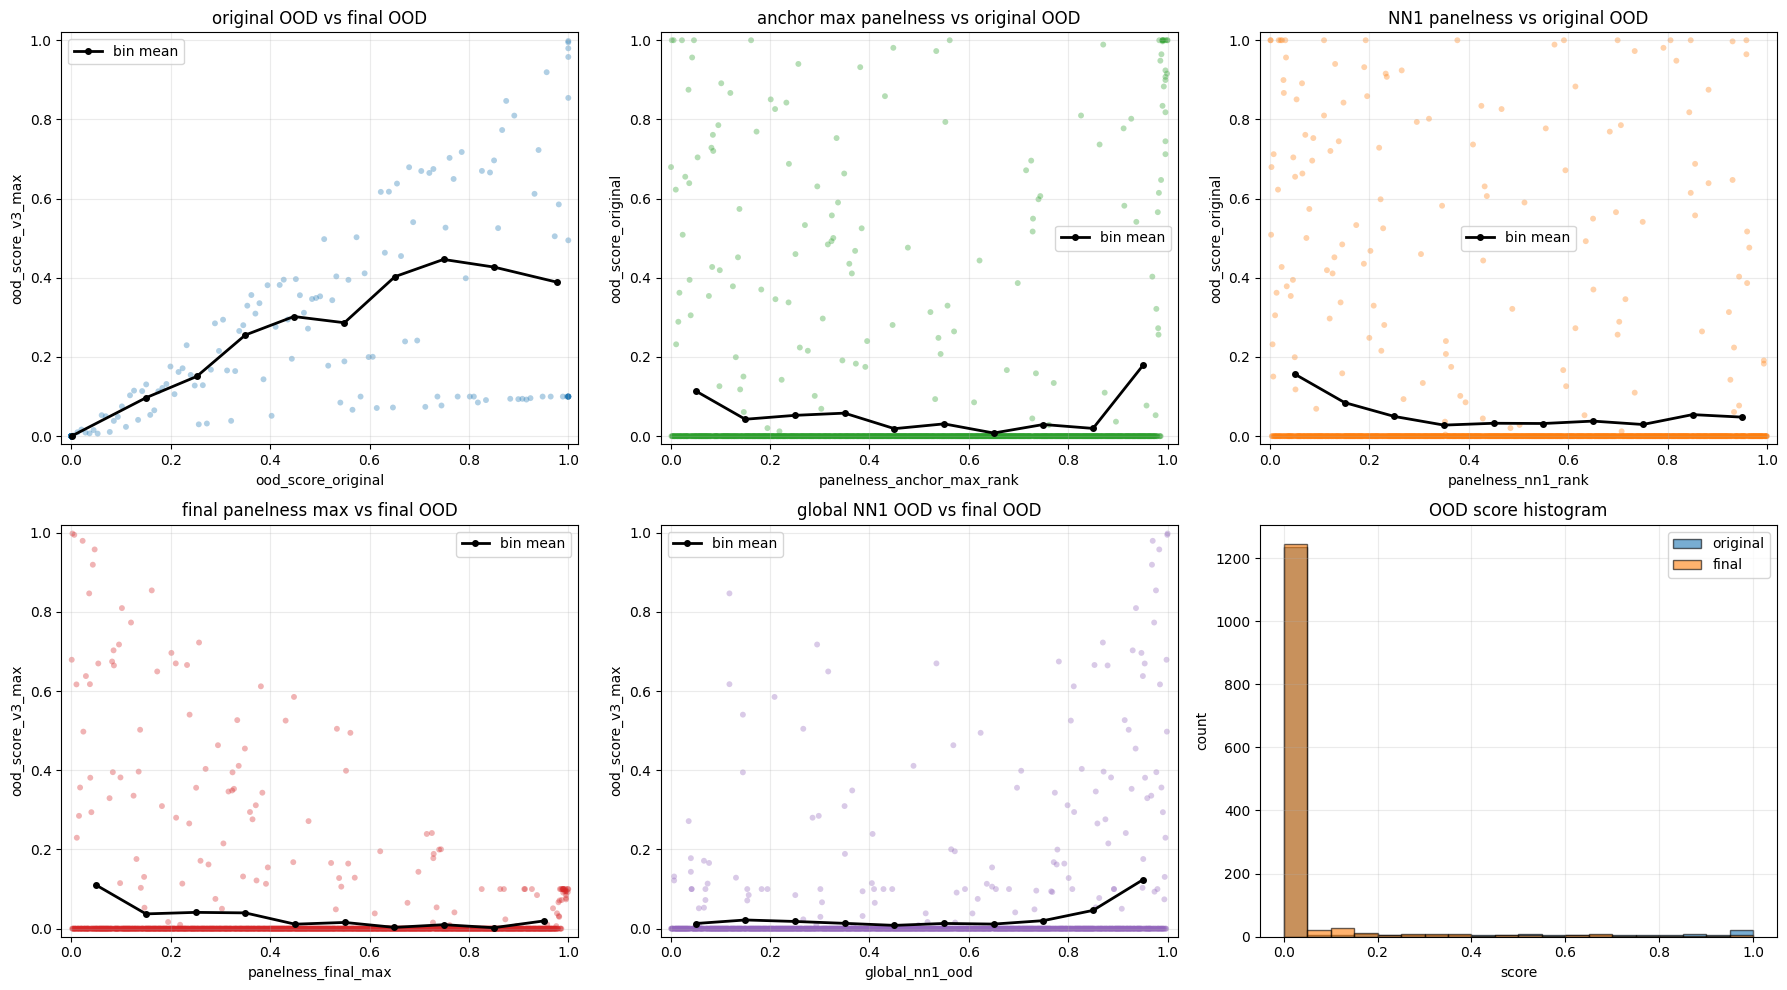

saved OOD diagnostic plot: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_070104_v3_20260701_214839/visualizations/ood_v3_panelness_diagnostics.png


In [11]:
def add_binned_mean_line(ax, df, x_col, y_col, bins=10):
    plot_df = df[[x_col, y_col]].dropna().copy()
    if plot_df.empty:
        return
    x_bins = pd.cut(plot_df[x_col], bins=np.linspace(0, 1, bins + 1), include_lowest=True)
    line_df = (
        plot_df.groupby(x_bins, observed=False)
        .agg(x_mean=(x_col, "mean"), y_mean=(y_col, "mean"), count=(y_col, "size"))
        .dropna(subset=["x_mean", "y_mean"])
        .reset_index(drop=True)
    )
    if not line_df.empty:
        ax.plot(line_df["x_mean"], line_df["y_mean"], color="black", linewidth=2, marker="o", markersize=4, label="bin mean")
        ax.legend(loc="best")


def scatter_xy(ax, df, x_col, y_col, title, color="tab:blue"):
    plot_df = df[[x_col, y_col]].dropna().copy()
    ax.scatter(plot_df[x_col], plot_df[y_col], s=18, alpha=0.35, color=color, edgecolors="none")
    add_binned_mean_line(ax, plot_df, x_col, y_col)
    ax.set_title(title)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.grid(alpha=0.25)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.reshape(-1)
scatter_xy(axes[0], score_df, "ood_score_original", FINAL_OOD_COL, "original OOD vs final OOD", color="tab:blue")
scatter_xy(axes[1], score_df, "panelness_anchor_max_rank", "ood_score_original", "anchor max panelness vs original OOD", color="tab:green")
scatter_xy(axes[2], score_df, "panelness_nn1_rank", "ood_score_original", "NN1 panelness vs original OOD", color="tab:orange")
scatter_xy(axes[3], score_df, "panelness_final_max", FINAL_OOD_COL, "final panelness max vs final OOD", color="tab:red")
scatter_xy(axes[4], score_df, "global_nn1_ood", FINAL_OOD_COL, "global NN1 OOD vs final OOD", color="tab:purple")
axes[5].hist(score_df["ood_score_original"], bins=np.linspace(0, 1, 21), alpha=0.6, label="original", edgecolor="black")
axes[5].hist(score_df[FINAL_OOD_COL], bins=np.linspace(0, 1, 21), alpha=0.6, label="final", edgecolor="black")
axes[5].set_title("OOD score histogram")
axes[5].set_xlabel("score")
axes[5].set_ylabel("count")
axes[5].legend(loc="best")
axes[5].grid(alpha=0.25)

plt.tight_layout()
OOD_DIAGNOSTIC_PLOT_PATH = VIS_DIR / "ood_v3_panelness_diagnostics.png"
fig.savefig(OOD_DIAGNOSTIC_PLOT_PATH, dpi=160, bbox_inches="tight")
plt.show()
print("saved OOD diagnostic plot:", OOD_DIAGNOSTIC_PLOT_PATH)

## 11. Top50 이미지 export

기존 OOD와 v3 OOD 후보 각각의 top50 이미지를 폴더와 grid PNG로 저장한다. 이미지 제목에는 기존 OOD, v3 OOD, anchor panelness, NN1 panelness를 함께 표시한다.

In [12]:
def load_rgb(path):
    return Image.open(path).convert("RGB")


def safe_score_text(value, digits=4):
    return f"{float(value):.{digits}f}".replace("-", "m").replace(".", "p")


def safe_filename_part(value, max_len=80):
    text = str(value)
    text = re.sub(r"[^A-Za-z0-9_.-]+", "_", text).strip("_")
    return (text[:max_len] or "na")


def method_from_score_col(score_col):
    for method in ANCHOR_METHOD_TO_PANELNESS_COL:
        if score_col == f"ood_score_v3_{method}":
            return method
    return "max"


def panelness_col_for_score_col(score_col):
    method = method_from_score_col(score_col)
    return ANCHOR_METHOD_TO_PANELNESS_COL.get(method, "panelness_anchor_max_rank")


def copy_top_images(df, score_col, n=50):
    score_dir = TOP50_DIR / score_col
    score_dir.mkdir(parents=True, exist_ok=True)
    top = df.sort_values(score_col, ascending=False).head(n).copy()
    rows = []
    panel_col = panelness_col_for_score_col(score_col)
    for rank, (_, row) in enumerate(top.iterrows(), start=1):
        src_path = Path(row["path"])
        suffix = src_path.suffix if src_path.suffix else ".jpg"
        dst_name = (
            f"rank{rank:03d}_{score_col}_{safe_score_text(row[score_col])}_"
            f"{safe_filename_part(row['id'])}_label{int(row['label'])}_pred{int(row['pred_label'])}{suffix}"
        )
        dst_path = score_dir / dst_name
        if not src_path.exists():
            raise FileNotFoundError(src_path)
        shutil.copy2(src_path, dst_path)
        rows.append({
            "score_col": score_col,
            "rank": rank,
            "id": row["id"],
            "score": float(row[score_col]),
            "label": int(row["label"]),
            "pred_label": int(row["pred_label"]),
            "ood_score_original": float(row["ood_score_original"]),
            "final_ood_score": float(row[FINAL_OOD_COL]),
            "panelness_anchor_rank": float(row[panel_col]),
            "panelness_nn1_rank": float(row["panelness_nn1_rank"]),
            "source_path": str(src_path),
            "copied_path": str(dst_path),
        })
    return pd.DataFrame(rows)


def save_top_grid(df, score_col, n=50, cols=10):
    top = df.sort_values(score_col, ascending=False).head(n).copy()
    rows = math.ceil(len(top) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(2.8 * cols, 3.3 * rows))
    axes = np.array(axes).reshape(-1)
    for ax in axes:
        ax.axis("off")
    panel_col = panelness_col_for_score_col(score_col)
    method = method_from_score_col(score_col)
    for ax, (rank, (_, row)) in zip(axes, enumerate(top.iterrows(), start=1)):
        ax.imshow(load_rgb(row["path"]))
        ax.set_title(
            f"#{rank} {row['id']}\n"
            f"old={row['ood_score_original']:.3f} new={row[FINAL_OOD_COL]:.3f}\n"
            f"pa={row[panel_col]:.3f} nn1={row['panelness_nn1_rank']:.3f}\n"
            f"method={method}",
            fontsize=7,
        )
    plt.tight_layout()
    save_path = VIS_DIR / f"top50_{score_col}.png"
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    return save_path

top50_export_cols = ["ood_score_original", "global_nn1_ood", "ood_score_v3_max", "ood_score_v3_top3", "ood_score_v3_top5", "ood_score_v3_proto"]
top50_index_parts = []
grid_paths = []
for col in top50_export_cols:
    top50_index_parts.append(copy_top_images(score_df, col, n=TOP50_N))
    grid_paths.append({"score_col": col, "grid_path": str(save_top_grid(score_df, col, n=TOP50_N, cols=10))})

top50_index = pd.concat(top50_index_parts, ignore_index=True)
top50_index.to_csv(TOP50_INDEX_PATH, index=False)
grid_df = pd.DataFrame(grid_paths)
grid_df.to_csv(TABLE_DIR / "top50_grid_paths.csv", index=False)

print("saved top50 index:", TOP50_INDEX_PATH)
display(top50_index.groupby("score_col").size().reset_index(name="copied_count"))
display(grid_df)

saved top50 index: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_070104_v3_20260701_214839/top50_images/top50_image_index.csv


,score_col,copied_count
0,global_nn1_ood,50
1,ood_score_original,50
2,ood_score_v3_max,50
3,ood_score_v3_proto,50
4,ood_score_v3_top3,50
5,ood_score_v3_top5,50


,score_col,grid_path
0,ood_score_original,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
1,global_nn1_ood,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
2,ood_score_v3_max,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
3,ood_score_v3_top3,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
4,ood_score_v3_top5,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
5,ood_score_v3_proto,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...


## 12. score-bin 분포와 구간별 샘플 폴더 export

v1/v2와 같이 점수 구간별 샘플을 별도 폴더에 복사한다. v3에서는 기존 OOD와 최종 OOD를 같이 비교한다.

,score_bin,count,score_min,score_max,score_mean,confidence_median,original_ood_median,final_ood_median,panelness_anchor_max_median,panelness_nn1_median,dup_positive,score_col,ratio
0,0.00-0.05,1211,0.000000,0.000000,0.000000,0.996234,0.000000,0.000000,0.506589,0.443631,0,dup_score,0.886530
1,0.05-0.10,14,0.062500,0.062500,0.062500,0.999953,0.000000,0.000000,0.746340,0.856881,14,dup_score,0.010249
4,0.20-0.25,16,0.250000,0.250000,0.250000,0.998897,0.000000,0.000000,0.662152,0.911420,16,dup_score,0.011713
11,0.55-0.60,36,0.562500,0.562500,0.562500,0.997760,0.000000,0.000000,0.396047,0.905930,36,dup_score,0.026354
19,0.95-1.00,89,1.000000,1.000000,1.000000,0.998672,0.000000,0.000000,0.436310,0.957174,89,dup_score,0.065154
20,0.00-0.05,1235,0.000000,0.044770,0.000119,0.997551,0.000000,0.000000,0.505857,0.513177,147,ood_score_original,0.904100
21,0.05-0.10,6,0.052910,0.093610,0.073260,0.771481,0.073260,0.043639,0.571376,0.513177,1,ood_score_original,0.004392
22,0.10-0.15,6,0.101750,0.142450,0.122100,0.980817,0.122100,0.089190,0.256589,0.489385,0,ood_score_original,0.004392
23,0.15-0.20,7,0.150590,0.199430,0.175010,0.927393,0.175010,0.121729,0.372621,0.364568,2,ood_score_original,0.005124
24,0.20-0.25,6,0.207570,0.248270,0.227920,0.932592,0.227920,0.158413,0.335652,0.288982,1,ood_score_original,0.004392


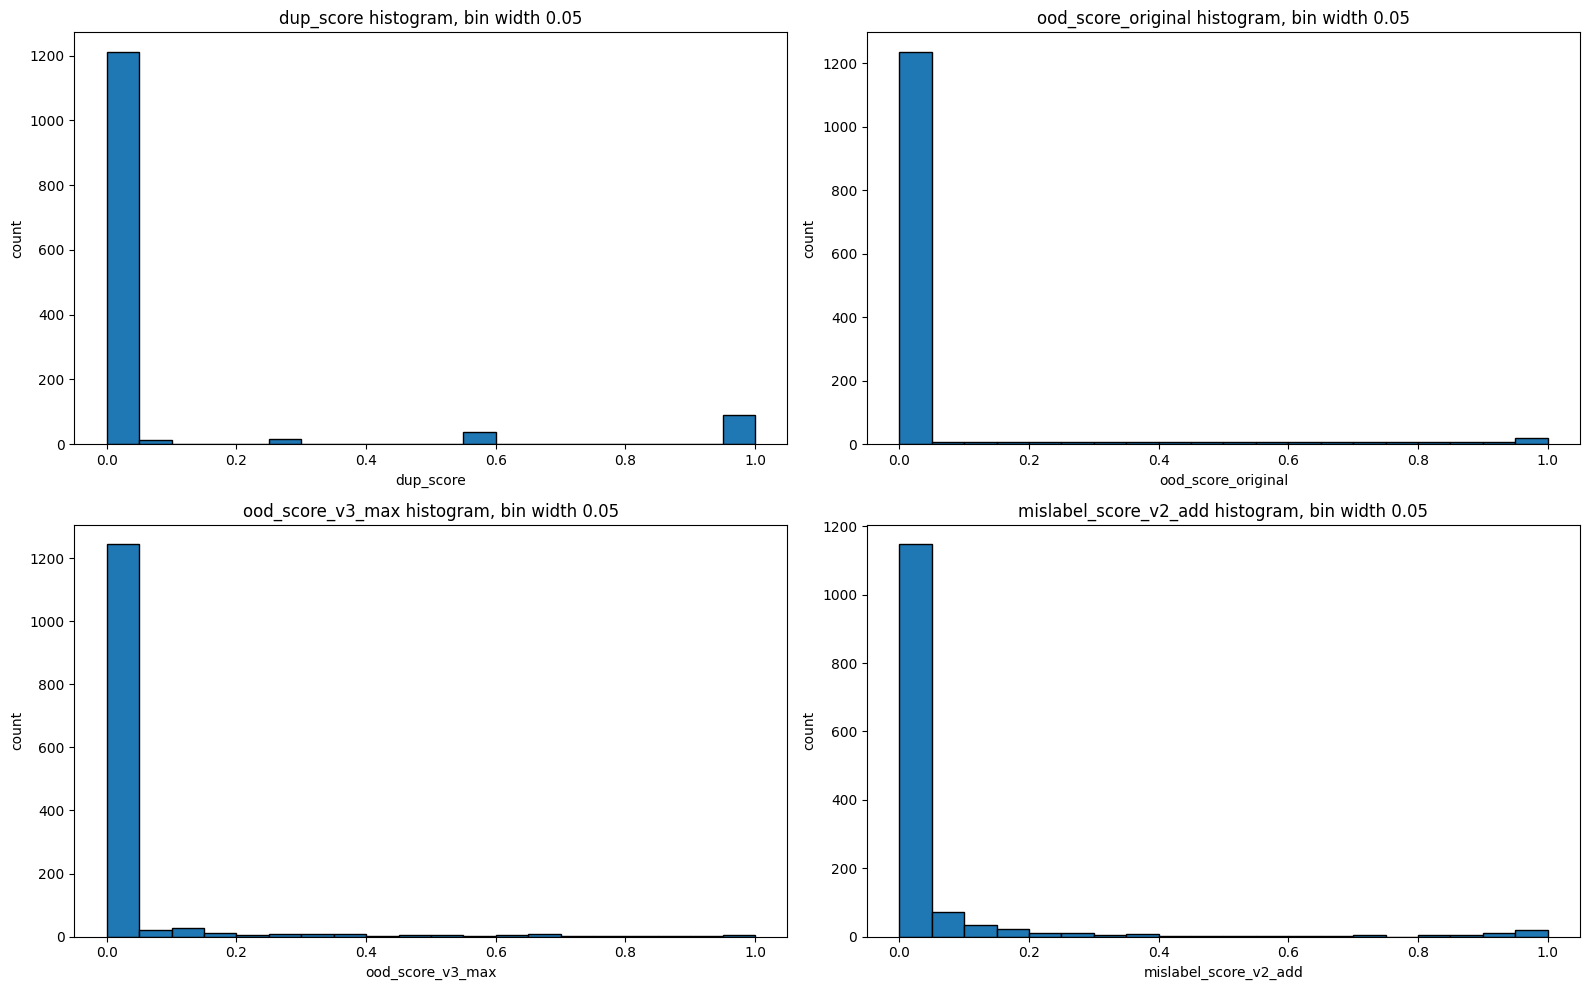

saved score-bin histogram: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_070104_v3_20260701_214839/visualizations/score_bin_histograms.png
saved score-bin sample index: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_070104_v3_20260701_214839/score_bin_sample_exports/score_sample_index.csv


,score_col,score_bin,sample_count
0,dup_score,0.00-0.05,5
1,dup_score,0.05-0.10,5
2,dup_score,0.20-0.25,5
3,dup_score,0.55-0.60,5
4,dup_score,0.95-1.00,5
5,mislabel_score_v2_add,0.00-0.05,5
6,mislabel_score_v2_add,0.05-0.10,5
7,mislabel_score_v2_add,0.10-0.15,5
8,mislabel_score_v2_add,0.15-0.20,5
9,mislabel_score_v2_add,0.20-0.25,5


In [13]:
score_bin_edges = np.round(np.linspace(0.0, 1.0, 21), 2)
score_bin_labels = [f"{score_bin_edges[i]:.2f}-{score_bin_edges[i + 1]:.2f}" for i in range(len(score_bin_edges) - 1)]
score_bin_export_cols = list(dict.fromkeys([DUP_COL_FOR_SUBMISSION, OOD_RAW_COL, FINAL_OOD_COL, MISLABEL_COL_FOR_SUBMISSION]))

for col in score_bin_export_cols:
    score_df[f"{col}_bin"] = pd.cut(score_df[col], bins=score_bin_edges, labels=score_bin_labels, include_lowest=True)


def make_score_bin_stats(df, score_col):
    bin_col = f"{score_col}_bin"
    stats = (
        df.groupby(bin_col, observed=False)
        .agg(
            count=("id", "size"),
            score_min=(score_col, "min"),
            score_max=(score_col, "max"),
            score_mean=(score_col, "mean"),
            confidence_median=("confidence", "median"),
            original_ood_median=("ood_score_original", "median"),
            final_ood_median=(FINAL_OOD_COL, "median"),
            panelness_anchor_max_median=("panelness_anchor_max_rank", "median"),
            panelness_nn1_median=("panelness_nn1_rank", "median"),
            dup_positive=(DUP_COL_FOR_SUBMISSION, lambda s: int((s > 0).sum())),
        )
        .reset_index()
        .rename(columns={bin_col: "score_bin"})
    )
    stats["score_col"] = score_col
    stats["ratio"] = stats["count"] / len(df)
    return stats

score_bin_stats = pd.concat([make_score_bin_stats(score_df, col) for col in score_bin_export_cols], ignore_index=True)
score_bin_stats.to_csv(TABLE_DIR / "score_bin_stats.csv", index=False)
display(score_bin_stats.query("count > 0"))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.reshape(-1)
for ax, col in zip(axes, score_bin_export_cols):
    ax.hist(score_df[col], bins=score_bin_edges, edgecolor="black")
    ax.set_title(f"{col} histogram, bin width 0.05")
    ax.set_xlabel(col)
    ax.set_ylabel("count")
for ax in axes[len(score_bin_export_cols):]:
    ax.axis("off")
plt.tight_layout()
SCORE_BIN_HIST_PATH = VIS_DIR / "score_bin_histograms.png"
fig.savefig(SCORE_BIN_HIST_PATH, dpi=160, bbox_inches="tight")
plt.show()
print("saved score-bin histogram:", SCORE_BIN_HIST_PATH)


def bin_folder_name(rank, bin_label):
    lo, hi = str(bin_label).split("-")
    return f"bin_{rank:02d}_{safe_filename_part(lo)}_{safe_filename_part(hi)}"


def export_score_bin_samples(df, score_col, n_per_bin=5):
    bin_col = f"{score_col}_bin"
    score_dir = SCORE_SAMPLE_DIR / score_col
    score_dir.mkdir(parents=True, exist_ok=True)
    exported_rows = []
    ranked_df = df.sort_values(score_col, ascending=False).copy()
    for bin_rank, bin_label in enumerate(reversed(score_bin_labels), start=1):
        bin_df = ranked_df[ranked_df[bin_col].astype(str).eq(str(bin_label))]
        if bin_df.empty:
            continue
        bin_dir = score_dir / bin_folder_name(bin_rank, bin_label)
        bin_dir.mkdir(parents=True, exist_ok=True)
        for local_rank, (_, row) in enumerate(bin_df.head(n_per_bin).iterrows(), start=1):
            src_path = Path(row["path"])
            suffix = src_path.suffix if src_path.suffix else ".jpg"
            dst_name = (
                f"rank{local_rank:02d}_{score_col}_{safe_score_text(row[score_col])}_"
                f"{safe_filename_part(row['id'])}_label{int(row['label'])}_pred{int(row['pred_label'])}{suffix}"
            )
            dst_path = bin_dir / dst_name
            if not src_path.exists():
                raise FileNotFoundError(src_path)
            shutil.copy2(src_path, dst_path)
            exported_rows.append({
                "score_col": score_col,
                "score_bin": str(bin_label),
                "bin_rank_high_to_low": bin_rank,
                "rank_in_bin": local_rank,
                "id": row["id"],
                "score": float(row[score_col]),
                "ood_score_original": float(row["ood_score_original"]),
                "final_ood_score": float(row[FINAL_OOD_COL]),
                "panelness_anchor_max_rank": float(row["panelness_anchor_max_rank"]),
                "panelness_nn1_rank": float(row["panelness_nn1_rank"]),
                "label": int(row["label"]),
                "pred_label": int(row["pred_label"]),
                "copied_path": str(dst_path),
            })
    return pd.DataFrame(exported_rows)

score_sample_index = pd.concat([export_score_bin_samples(score_df, col, n_per_bin=SCORE_BIN_N_PER_BIN) for col in score_bin_export_cols], ignore_index=True)
score_sample_index.to_csv(SCORE_SAMPLE_INDEX_PATH, index=False)
print("saved score-bin sample index:", SCORE_SAMPLE_INDEX_PATH)
display(score_sample_index.groupby(["score_col", "score_bin"]).size().reset_index(name="sample_count"))

## 13. 최종 검증과 검수 포인트

서버 AP 점수는 여기서 계산하지 않는다. 이 셀은 제출 파일 형식, score 범위, 주요 산출물 존재 여부만 확인한다.

In [14]:
validate_submission(submission_default, sample)
for method in ANCHOR_METHOD_TO_PANELNESS_COL:
    validate_submission(make_submission(f"ood_score_v3_{method}"), sample)

required_output_paths = [
    DETAIL_V3_PATH, SUBMISSION_DEFAULT_PATH, CONFIG_PATH, TOP50_INDEX_PATH,
    SCORE_SAMPLE_INDEX_PATH, OOD_DIAGNOSTIC_PLOT_PATH, SCORE_BIN_HIST_PATH,
    TABLE_DIR / "ood_v3_ablation_describe.csv",
    TABLE_DIR / "ood_v3_top50_overlap.csv",
    TABLE_DIR / "ood_v3_top50_profile.csv",
    TABLE_DIR / "top50_grid_paths.csv",
    TABLE_DIR / "panel_anchor_index.csv",
]
for path in required_output_paths:
    if not Path(path).exists():
        raise FileNotFoundError(path)

final_score_cols = [MISLABEL_COL_FOR_SUBMISSION, DUP_COL_FOR_SUBMISSION, FINAL_OOD_COL]
if score_df[final_score_cols].isna().any().any():
    raise ValueError("final score columns contain NaN")
if not score_df[final_score_cols].apply(lambda s: s.between(0, 1).all()).all():
    raise ValueError("final scores must be in [0, 1]")

print("Final validation passed.")
print("OUTPUT_DIR:", OUTPUT_DIR)
print("detail:", DETAIL_V3_PATH)
print("default submission:", SUBMISSION_DEFAULT_PATH)
print("FINAL_OOD_COL:", FINAL_OOD_COL)
print("top50 image folders:", TOP50_DIR)
print("score-bin sample folders:", SCORE_SAMPLE_DIR)
print("tables:", TABLE_DIR)

final_summary = pd.DataFrame({
    "score": [MISLABEL_COL_FOR_SUBMISSION, DUP_COL_FOR_SUBMISSION, "ood_score_original", FINAL_OOD_COL],
    "nonzero_count": [
        int((score_df[MISLABEL_COL_FOR_SUBMISSION] > 0).sum()),
        int((score_df[DUP_COL_FOR_SUBMISSION] > 0).sum()),
        int((score_df["ood_score_original"] > 0).sum()),
        int((score_df[FINAL_OOD_COL] > 0).sum()),
    ],
    "max": [
        float(score_df[MISLABEL_COL_FOR_SUBMISSION].max()),
        float(score_df[DUP_COL_FOR_SUBMISSION].max()),
        float(score_df["ood_score_original"].max()),
        float(score_df[FINAL_OOD_COL].max()),
    ],
})
display(final_summary)

inspection_cols = [
    "id", "path", "label", "pred_label", "ood_score_original", FINAL_OOD_COL,
    "panelness_anchor_max_rank", "panelness_nn1_rank", "global_nn1_id", "global_nn1_cos",
]
print("Top final OOD rows for manual inspection")
display(score_df.sort_values(FINAL_OOD_COL, ascending=False)[inspection_cols].head(30))

Final validation passed.
OUTPUT_DIR: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_070104_v3_20260701_214839
detail: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_070104_v3_20260701_214839/trackB_v3_scores_detail.csv
default submission: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_070104_v3_20260701_214839/submission_trackB_ood_v3_anchor.csv
FINAL_OOD_COL: ood_score_v3_max
top50 image folders: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_070104_v3_20260701_214839/top50_images
score-bin sample folders: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_070104_v3_20260701_214839/score_bin_sample_exports
tables: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_070104_v3_20260701_214839/tables


,score,nonzero_count,max
0,mislabel_score_v2_add,1333,0.999970
1,dup_score,155,1.000000
2,ood_score_original,137,1.000000
3,ood_score_v3_max,137,0.998023


Top final OOD rows for manual inspection


,id,path,label,pred_label,ood_score_original,ood_score_v3_max,panelness_anchor_max_rank,panelness_nn1_rank,global_nn1_id,global_nn1_cos
20,train_00020,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,1,1,1.000000,0.998023,0.002196,0.000732,train_01141,0.684365
314,train_00314,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,0,0,1.000000,0.994729,0.005857,0.001464,train_00522,0.689018
762,train_00762,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,1,1,1.000000,0.979575,0.022694,0.030747,train_00248,0.770303
910,train_00910,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,0,0,1.000000,0.957833,0.046852,0.017570,train_01253,0.751817
1283,train_01283,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,1,1,0.956451,0.919271,0.043192,0.032211,train_00214,0.772982
204,train_00204,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,0,0,1.000000,0.854392,0.161786,0.024158,train_01327,0.757933
973,train_00973,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,0,0,0.875051,0.846801,0.035871,0.882504,train_01201,0.980991
51,train_00051,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,0,0,0.891331,0.809702,0.101757,0.064422,train_00631,0.808576
726,train_00726,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,0,0,0.866911,0.773239,0.120059,0.027818,train_00796,0.762573
1113,train_01113,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,0,1,0.940171,0.722748,0.256955,0.131040,train_01304,0.835953


## 14. 해석 가이드

실행 후 아래 항목을 보고 최종 OOD 컬럼을 선택한다.

1. `visualizations/top50_ood_score_original.png`와 `visualizations/top50_ood_score_v3_*.png`를 비교한다.
2. 기존 OOD top50에 많던 태양광 패널 이미지가 v3 top50에서 줄었는지 확인한다.
3. 먼지 많음, 반사 심함, 각도 특이함, 청소 장면은 OOD보다 hard in-domain 또는 mislabel 후보로 보는 것이 자연스럽다.
4. `max`는 anchor 하나와만 비슷해도 패널로 살리므로 특이한 패널 FP를 줄이는 데 유리하다.
5. `top3/top5`는 여러 anchor와 두루 비슷한 이미지를 더 안정적으로 살리지만, anchor 다양성이 부족하면 특이한 패널을 덜 살릴 수 있다.
6. `proto`는 단순하지만 panel 형태가 다양하면 평균 embedding이 흐려질 수 있다.
7. 최종 제출은 `FINAL_OOD_COL`과 `submission_trackB_ood_v3_anchor.csv`를 기준으로 한다.

In [15]:
FINAL_OOD_COL = "ood_score_v3_max"
PANELNESS_COL = "panelness_final_max"   # 실제 demotion에 쓰인 최종 panelness
OOD_RAW_COL = "ood_score_original"
ID_COL = "id"

tmp = score_df[[ID_COL, OOD_RAW_COL, PANELNESS_COL, FINAL_OOD_COL]].copy()

strength = PANELNESS_STRENGTH
thr = PANELNESS_CAP_THRESHOLD
cap = PANELNESS_CAP_VALUE

expected = tmp[OOD_RAW_COL].values * (1 - strength * tmp[PANELNESS_COL].values)
expected = np.where(
    tmp[PANELNESS_COL].values > thr,
    np.minimum(expected, cap),
    expected
)

tmp["expected_ood"] = expected
tmp["diff_expected_vs_saved"] = tmp[FINAL_OOD_COL] - tmp["expected_ood"]

display(
    tmp.sort_values("diff_expected_vs_saved", key=lambda s: s.abs(), ascending=False)
       .head(30)
)

print(tmp["diff_expected_vs_saved"].abs().describe())

,id,ood_score_original,panelness_final_max,ood_score_v3_max,expected_ood,diff_expected_vs_saved
0,train_00000,0.000000,0.814056,0.000000,0.000000,0.0
908,train_00908,0.000000,0.257687,0.000000,0.000000,0.0
916,train_00916,0.000000,0.766471,0.000000,0.000000,0.0
915,train_00915,0.000000,0.778184,0.000000,0.000000,0.0
914,train_00914,0.000000,0.244510,0.000000,0.000000,0.0
913,train_00913,0.000000,0.313324,0.000000,0.000000,0.0
912,train_00912,0.000000,0.344070,0.000000,0.000000,0.0
911,train_00911,0.000000,0.901171,0.000000,0.000000,0.0
910,train_00910,1.000000,0.046852,0.957833,0.957833,0.0
909,train_00909,0.000000,0.065154,0.000000,0.000000,0.0


count    1366.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: diff_expected_vs_saved, dtype: float64


In [16]:
FINAL_OOD_COL = "ood_score_v3_debug_force"
ID_COL = "id"

ood_new = score_df["ood_score_original"].values.copy()
p = score_df["panelness_final_max"].values

ood_new = ood_new * (1 - 0.95 * p)
ood_new = np.where(p > 0.80, np.minimum(ood_new, 0.10), ood_new)
ood_new = np.where(p > 0.90, np.minimum(ood_new, 0.05), ood_new)

is_anchor = score_df[ID_COL].isin(panel_anchor_ids).values
ood_new = np.where(is_anchor, 0.0, ood_new)

score_df[FINAL_OOD_COL] = ood_new

display(
    score_df.sort_values(FINAL_OOD_COL, ascending=False)[
        [ID_COL, "ood_score_original", "panelness_anchor_max_rank",
         "panelness_nn1_rank", "panelness_final_max", FINAL_OOD_COL]
    ].head(50)
)

display(
    score_df[score_df[ID_COL].isin(panel_anchor_ids)][
        [ID_COL, "ood_score_original", "panelness_anchor_max_rank",
         "panelness_nn1_rank", "panelness_final_max", FINAL_OOD_COL]
    ]
)

,id,ood_score_original,panelness_anchor_max_rank,panelness_nn1_rank,panelness_final_max,ood_score_v3_debug_force
20,train_00020,1.000000,0.002196,0.000732,0.002196,0.997914
314,train_00314,1.000000,0.005857,0.001464,0.005857,0.994436
762,train_00762,1.000000,0.022694,0.030747,0.022694,0.978441
910,train_00910,1.000000,0.046852,0.017570,0.046852,0.955490
1283,train_01283,0.956451,0.043192,0.032211,0.043192,0.917206
204,train_00204,1.000000,0.161786,0.024158,0.161786,0.846303
973,train_00973,0.875051,0.035871,0.882504,0.035871,0.845231
51,train_00051,0.891331,0.101757,0.064422,0.101757,0.805167
726,train_00726,0.866911,0.120059,0.027818,0.120059,0.768035
1220,train_01220,0.785511,0.095900,0.706076,0.095900,0.713946


,id,ood_score_original,panelness_anchor_max_rank,panelness_nn1_rank,panelness_final_max,ood_score_v3_debug_force
12,train_00012,1.000000,0.995608,0.192533,0.995608,0.0
101,train_00101,0.834351,0.989751,0.425329,0.989751,0.0
149,train_00149,1.000000,1.000000,0.699488,1.000000,0.0
179,train_00179,1.000000,0.989751,0.806003,0.989751,0.0
325,train_00325,0.818071,0.995608,0.843704,0.995608,0.0
365,train_00365,1.000000,0.989751,0.108712,0.989751,0.0
423,train_00423,0.899471,0.995608,0.027086,0.995608,0.0
459,train_00459,1.000000,0.989751,0.021230,0.989751,0.0
562,train_00562,1.000000,0.992313,0.591508,0.992313,0.0
587,train_00587,0.883191,0.992313,0.614568,0.992313,0.0
